<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/NeuralNetworks/NN_Training_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single-Layer, Two-Layer, and Three-Layer Neural Networks for Regression

**Math 528: Mathematical Foundations of Machine Learning and Data Science**  
**Instructor:** Mitchel Colebank

This notebook describes and implements three neural networks for a one-dimensional regression problem:

1. A **single-layer neural network**, which maps inputs directly to outputs.
2. A **two-layer neural network**, which has one hidden layer and one output layer.
3. A **three-layer neural network**, which has two hidden layers and one output layer.

All models are implemented from scratch using `numpy`. The code follows the style of the provided homework script: dictionaries for layer sizes and options, mini-batch gradient descent, explicit forward propagation, explicit backpropagation, and training-loss plots.


## 1. Regression Problem

We will approximate the nonlinear function

$$
f(x) = 3\sin(1.5x) + x^2.
$$

The training set is intentionally small, so the examples emphasize how network architecture changes the flexibility of the model.


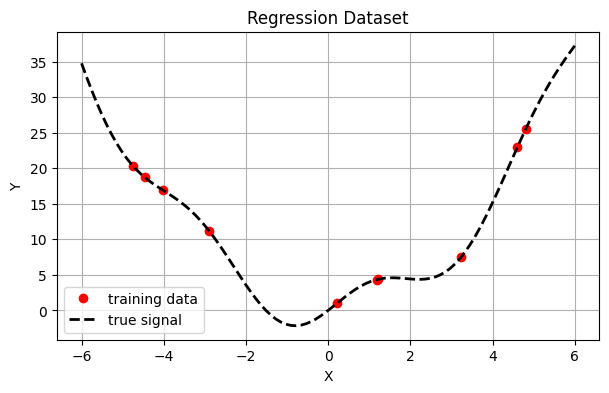

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(52)

# Number of observations
m = 10

# Regression function
f = lambda x: 3 * np.sin(1.5 * x) + x**2

# Training data
X = np.random.uniform(-5, 5, (1, m))
Y = f(X).reshape(1, -1)

# Test grid for plotting
X_test = np.linspace(-6, 6, 100).reshape(1, -1)
Y_test = f(X_test)



plt.figure(figsize=(7, 4))
plt.plot(X.flatten(), Y.flatten(), 'ro', markerfacecolor='r', label='training data')
plt.plot(X_test.flatten(), Y_test.flatten(), '--k', linewidth=2, label='true signal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regression Dataset')
plt.grid(True)
plt.legend()
plt.show()


In [67]:
# Shared optimization options
opts = {
    'learning_rate': 1e-3,
    'epochs': 4000,
    'batch_size': 20,
    'loss': 'mse',
    'verbose': True,
    'seed': 1,
}

## 2. Activation Functions

Each layer first computes an affine transformation

$$
Z = WA + b,
$$

then applies an activation function

$$
A = \sigma(Z).
$$

The output layer uses a linear activation for regression.


In [68]:
def apply_activation(Z, activation_name):
    name = activation_name.lower()

    if name == 'sigmoid':
        A = 1 / (1 + np.exp(-Z))
    elif name == 'tanh':
        A = np.tanh(Z)
    elif name == 'relu':
        A = np.maximum(0, Z)
    elif name == 'linear':
        A = Z
    else:
        raise ValueError(f'Unknown activation: {activation_name}')

    return A


def activation_derivative_from_z(Z, activation_name):
    name = activation_name.lower()

    if name == 'sigmoid':
        S = 1 / (1 + np.exp(-Z))
        dA = S * (1 - S)
    elif name == 'tanh':
        T = np.tanh(Z)
        dA = 1 - T**2
    elif name == 'relu':
        dA = (Z > 0).astype(float)
    elif name == 'linear':
        dA = np.ones_like(Z)
    else:
        raise ValueError(f'Unknown activation: {activation_name}')

    return dA


## 3. Loss Function

For regression, we use mean squared error:

$$
J(\theta) = \frac{1}{m}\sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2.
$$


In [69]:
def compute_loss(Yhat, Y, loss_type='mse'):
    if loss_type.lower() == 'mse':
        loss = np.mean(np.sum((Yhat - Y)**2, axis=0))
    else:
        raise ValueError(f'Unsupported loss type: {loss_type}')

    return loss


## 4. Single-Layer Neural Network

A single-layer neural network has one trainable layer:

$$
Z^{[1]} = W^{[1]}X + b^{[1]},
$$

$$
\hat{Y} = A^{[1]} = \sigma_{out}\left(Z^{[1]}\right).
$$

With a linear output activation, this is a linear regression model. It is included as a useful baseline.


In [70]:
def initialize_single_layer_parameters(layer_sizes):
    n_in = layer_sizes['input']
    n_out = layer_sizes['output']

    # This initialization comes from some theoretical analysis
    # on how we can initialize neural networks
    limit = np.sqrt(6 / (n_in + n_out))

    params = {
        'W1': -limit + 2 * limit * np.random.rand(n_out, n_in),
        'b1': np.zeros((n_out, 1)),
    }
    return params


def forward_single_layer(X, params, activations):
    Z1 = params['W1'] @ X + params['b1']
    A1 = apply_activation(Z1, activations['output'])

    cache = {
        'Z1': Z1,
        'A1': A1,
    }
    return cache


def backward_single_layer(X, Y, params, cache, activations, loss_type):
    m_batch = X.shape[1]

    if loss_type.lower() == 'mse':
        dA1 = 2 * (cache['A1'] - Y)
    else:
        raise ValueError(f'Unsupported loss type: {loss_type}')

    dZ1 = dA1 * activation_derivative_from_z(cache['Z1'], activations['output'])

    grads = {
        'dW1': (1 / m_batch) * (dZ1 @ X.T),
        'db1': (1 / m_batch) * np.sum(dZ1, axis=1, keepdims=True),
    }
    return grads


def train_single_layer_nn(X, Y, layer_sizes, activations, opts):
    n_in, m = X.shape
    n_out, mY = Y.shape

    if m != mY:
        raise ValueError('X and Y must have the same number of samples.')
    if layer_sizes['input'] != n_in:
        raise ValueError('layer_sizes.input must match size(X,1).')
    if layer_sizes['output'] != n_out:
        raise ValueError('layer_sizes.output must match size(Y,1).')

    if 'seed' in opts:
        np.random.seed(opts['seed'])

    params = initialize_single_layer_parameters(layer_sizes)
    history = {'loss': np.zeros((opts['epochs'],))}
    # The 'epoch' is the number of times you would like to
    # work through the entire dataset. So e.g., if we had 200 data points, with
    # a batch size of 20, running our model over 10 epochs would iterate
    # over the whole data set, in batches of 20 across 10 iterations, to train
    # the model
    for epoch in range(opts['epochs']):
        perm = np.random.permutation(m)
        X_shuf = X[:, perm]
        Y_shuf = Y[:, perm]

        num_batches = int(np.ceil(m / opts['batch_size']))
        epoch_loss = 0.0

        for b in range(num_batches):
            idx_start = b * opts['batch_size']
            idx_end = min((b + 1) * opts['batch_size'], m)

            Xb = X_shuf[:, idx_start:idx_end]
            Yb = Y_shuf[:, idx_start:idx_end]

            cache = forward_single_layer(Xb, params, activations)
            batch_loss = compute_loss(cache['A1'], Yb, opts['loss'])
            epoch_loss += batch_loss

            grads = backward_single_layer(Xb, Yb, params, cache, activations, opts['loss'])

            params['W1'] -= opts['learning_rate'] * grads['dW1']
            params['b1'] -= opts['learning_rate'] * grads['db1']

        history['loss'][epoch] = epoch_loss / num_batches

        if opts['verbose'] and (((epoch + 1) % max(1, opts['epochs'] // 10) == 0) or epoch == 0):
            print(f"Single-layer epoch {epoch + 1}/{opts['epochs']}, Loss = {history['loss'][epoch]:.6f}")

    return params, history


def predict_single_layer_nn(X, params, activations):
    cache = forward_single_layer(X, params, activations)
    return cache['A1']


### Train the Single-Layer Network


In [71]:
single_layer_sizes = {
    'input': 1,
    'output': 1,
}

single_activations = {
    'output': 'relu',
}

single_params, single_history = train_single_layer_nn(
    X, Y, single_layer_sizes, single_activations, opts
)

Yhat_single = predict_single_layer_nn(X_test, single_params, single_activations)


Single-layer epoch 1/4000, Loss = 228.672888
Single-layer epoch 400/4000, Loss = 127.324046
Single-layer epoch 800/4000, Loss = 127.319542
Single-layer epoch 1200/4000, Loss = 127.316769
Single-layer epoch 1600/4000, Loss = 127.314464
Single-layer epoch 2000/4000, Loss = 127.312548
Single-layer epoch 2400/4000, Loss = 127.310955
Single-layer epoch 2800/4000, Loss = 127.309632
Single-layer epoch 3200/4000, Loss = 127.308532
Single-layer epoch 3600/4000, Loss = 127.307618
Single-layer epoch 4000/4000, Loss = 127.306858


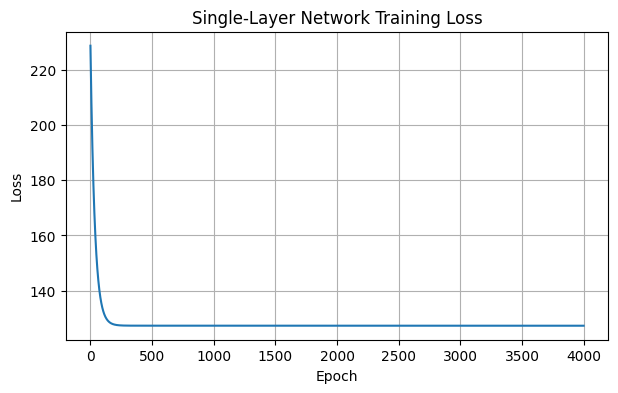

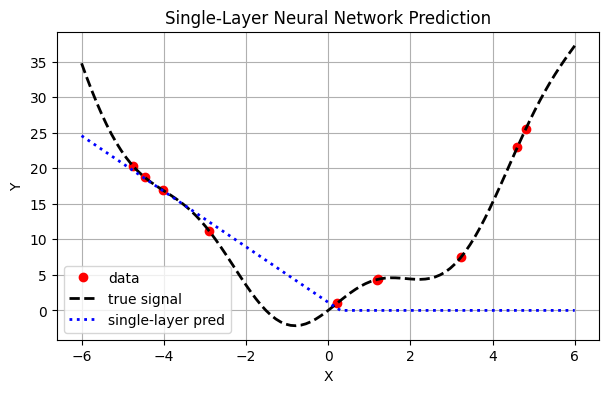

In [72]:
plt.figure(figsize=(7, 4))
plt.plot(single_history['loss'], linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Single-Layer Network Training Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(X.flatten(), Y.flatten(), 'ro', markerfacecolor='r', label='data')
plt.plot(X_test.flatten(), Y_test.flatten(), '--k', linewidth=2, label='true signal')
plt.plot(X_test.flatten(), Yhat_single.flatten(), ':b', linewidth=2, label='single-layer pred')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Single-Layer Neural Network Prediction')
plt.grid(True)
plt.legend()
plt.show()


## 5. Two-Layer Neural Network

A two-layer neural network has one hidden layer and one output layer:

$$
Z^{[1]} = W^{[1]}X + b^{[1]},
$$

$$
A^{[1]} = \sigma_1\left(Z^{[1]}\right),
$$

$$
Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]},
$$

$$
\hat{Y} = A^{[2]} = \sigma_{out}\left(Z^{[2]}\right).
$$

The hidden layer allows the model to learn nonlinear relationships.


In [73]:
def initialize_two_layer_parameters(layer_sizes):
    n_in = layer_sizes['input']
    n_h = layer_sizes['hidden']
    n_out = layer_sizes['output']

    limit1 = np.sqrt(6 / (n_in + n_h))
    limit2 = np.sqrt(6 / (n_h + n_out))

    params = {
        'W1': -limit1 + 2 * limit1 * np.random.rand(n_h, n_in),
        'b1': np.zeros((n_h, 1)),
        'W2': -limit2 + 2 * limit2 * np.random.rand(n_out, n_h),
        'b2': np.zeros((n_out, 1)),
    }
    return params


def forward_two_layer(X, params, activations):
    Z1 = params['W1'] @ X + params['b1']
    A1 = apply_activation(Z1, activations['hidden'])

    Z2 = params['W2'] @ A1 + params['b2']
    A2 = apply_activation(Z2, activations['output'])

    cache = {
        'Z1': Z1,
        'A1': A1,
        'Z2': Z2,
        'A2': A2,
    }
    return cache


def backward_two_layer(X, Y, params, cache, activations, loss_type):
    m_batch = X.shape[1]

    if loss_type.lower() == 'mse':
        dA2 = 2 * (cache['A2'] - Y)
    else:
        raise ValueError(f'Unsupported loss type: {loss_type}')

    dZ2 = dA2 * activation_derivative_from_z(cache['Z2'], activations['output'])

    grads = {}
    grads['dW2'] = (1 / m_batch) * (dZ2 @ cache['A1'].T)
    grads['db2'] = (1 / m_batch) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = params['W2'].T @ dZ2
    dZ1 = dA1 * activation_derivative_from_z(cache['Z1'], activations['hidden'])

    grads['dW1'] = (1 / m_batch) * (dZ1 @ X.T)
    grads['db1'] = (1 / m_batch) * np.sum(dZ1, axis=1, keepdims=True)

    return grads


def train_two_layer_nn(X, Y, layer_sizes, activations, opts):
    n_in, m = X.shape
    n_out, mY = Y.shape

    if m != mY:
        raise ValueError('X and Y must have the same number of samples.')
    if layer_sizes['input'] != n_in:
        raise ValueError('layer_sizes.input must match size(X,1).')
    if layer_sizes['output'] != n_out:
        raise ValueError('layer_sizes.output must match size(Y,1).')

    if 'seed' in opts:
        np.random.seed(opts['seed'])

    params = initialize_two_layer_parameters(layer_sizes)
    history = {'loss': np.zeros((opts['epochs'],))}

    for epoch in range(opts['epochs']):
        perm = np.random.permutation(m)
        X_shuf = X[:, perm]
        Y_shuf = Y[:, perm]

        num_batches = int(np.ceil(m / opts['batch_size']))
        epoch_loss = 0.0

        for b in range(num_batches):
            idx_start = b * opts['batch_size']
            idx_end = min((b + 1) * opts['batch_size'], m)

            Xb = X_shuf[:, idx_start:idx_end]
            Yb = Y_shuf[:, idx_start:idx_end]

            cache = forward_two_layer(Xb, params, activations)
            batch_loss = compute_loss(cache['A2'], Yb, opts['loss'])
            epoch_loss += batch_loss

            grads = backward_two_layer(Xb, Yb, params, cache, activations, opts['loss'])

            params['W1'] -= opts['learning_rate'] * grads['dW1']
            params['b1'] -= opts['learning_rate'] * grads['db1']
            params['W2'] -= opts['learning_rate'] * grads['dW2']
            params['b2'] -= opts['learning_rate'] * grads['db2']

        history['loss'][epoch] = epoch_loss / num_batches

        if opts['verbose'] and (((epoch + 1) % max(1, opts['epochs'] // 10) == 0) or epoch == 0):
            print(f"Two-layer epoch {epoch + 1}/{opts['epochs']}, Loss = {history['loss'][epoch]:.6f}")

    return params, history


def predict_two_layer_nn(X, params, activations):
    cache = forward_two_layer(X, params, activations)
    return cache['A2']


### Train the Two-Layer Network


In [74]:
# Shared optimization options
opts = {
    'learning_rate': 1e-3,
    'epochs': 4000,
    'batch_size': 5,
    'loss': 'mse',
    'verbose': True,
    'seed': 1,
}

In [75]:
two_layer_sizes = {
    'input': 1,
    'hidden': 20,
    'output': 1,
}

two_activations = {
    'hidden': 'tanh',
    'output': 'linear',
}

two_params, two_history = train_two_layer_nn(
    X, Y, two_layer_sizes, two_activations, opts
)

Yhat_two = predict_two_layer_nn(X_test, two_params, two_activations)


Two-layer epoch 1/4000, Loss = 250.089422
Two-layer epoch 400/4000, Loss = 46.647667
Two-layer epoch 800/4000, Loss = 11.054977
Two-layer epoch 1200/4000, Loss = 3.114212
Two-layer epoch 1600/4000, Loss = 1.480264
Two-layer epoch 2000/4000, Loss = 1.045815
Two-layer epoch 2400/4000, Loss = 0.862854
Two-layer epoch 2800/4000, Loss = 0.814082
Two-layer epoch 3200/4000, Loss = 0.758408
Two-layer epoch 3600/4000, Loss = 0.718875
Two-layer epoch 4000/4000, Loss = 0.703345


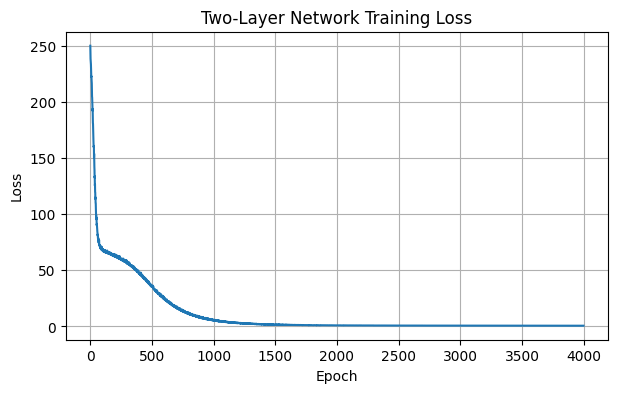

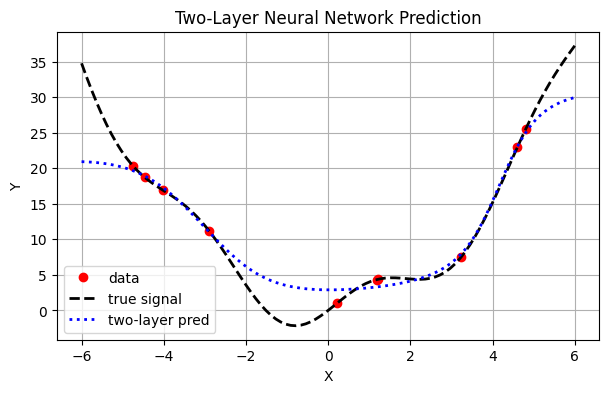

In [76]:
plt.figure(figsize=(7, 4))
plt.plot(two_history['loss'], linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Two-Layer Network Training Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(X.flatten(), Y.flatten(), 'ro', markerfacecolor='r', label='data')
plt.plot(X_test.flatten(), Y_test.flatten(), '--k', linewidth=2, label='true signal')
plt.plot(X_test.flatten(), Yhat_two.flatten(), ':b', linewidth=2, label='two-layer pred')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Two-Layer Neural Network Prediction')
plt.grid(True)
plt.legend()
plt.show()


## 6. Three-Layer Neural Network

A three-layer neural network has two hidden layers and one output layer:

$$
Z^{[1]} = W^{[1]}X + b^{[1]},
$$

$$
A^{[1]} = \sigma_1\left(Z^{[1]}\right),
$$

$$
Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]},
$$

$$
A^{[2]} = \sigma_2\left(Z^{[2]}\right),
$$

$$
Z^{[3]} = W^{[3]}A^{[2]} + b^{[3]},
$$

$$
\hat{Y} = A^{[3]} = \sigma_{out}\left(Z^{[3]}\right).
$$

This model is deeper than the two-layer network. The second hidden layer gives the model additional flexibility, although with only ten training points it may also overfit.


In [77]:
def initialize_three_layer_parameters(layer_sizes):
    n_in = layer_sizes['input']
    n_h1 = layer_sizes['hidden1']
    n_h2 = layer_sizes['hidden2']
    n_out = layer_sizes['output']

    limit1 = np.sqrt(6 / (n_in + n_h1))
    limit2 = np.sqrt(6 / (n_h1 + n_h2))
    limit3 = np.sqrt(6 / (n_h2 + n_out))

    params = {
        'W1': -limit1 + 2 * limit1 * np.random.rand(n_h1, n_in),
        'b1': np.zeros((n_h1, 1)),
        'W2': -limit2 + 2 * limit2 * np.random.rand(n_h2, n_h1),
        'b2': np.zeros((n_h2, 1)),
        'W3': -limit3 + 2 * limit3 * np.random.rand(n_out, n_h2),
        'b3': np.zeros((n_out, 1)),
    }
    return params


def forward_three_layer(X, params, activations):
    Z1 = params['W1'] @ X + params['b1']
    A1 = apply_activation(Z1, activations['hidden1'])

    Z2 = params['W2'] @ A1 + params['b2']
    A2 = apply_activation(Z2, activations['hidden2'])

    Z3 = params['W3'] @ A2 + params['b3']
    A3 = apply_activation(Z3, activations['output'])

    cache = {
        'Z1': Z1,
        'A1': A1,
        'Z2': Z2,
        'A2': A2,
        'Z3': Z3,
        'A3': A3,
    }
    return cache


def backward_three_layer(X, Y, params, cache, activations, loss_type):
    m_batch = X.shape[1]

    if loss_type.lower() == 'mse':
        dA3 = 2 * (cache['A3'] - Y)
    else:
        raise ValueError(f'Unsupported loss type: {loss_type}')

    dZ3 = dA3 * activation_derivative_from_z(cache['Z3'], activations['output'])

    grads = {}
    grads['dW3'] = (1 / m_batch) * (dZ3 @ cache['A2'].T)
    grads['db3'] = (1 / m_batch) * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = params['W3'].T @ dZ3
    dZ2 = dA2 * activation_derivative_from_z(cache['Z2'], activations['hidden2'])

    grads['dW2'] = (1 / m_batch) * (dZ2 @ cache['A1'].T)
    grads['db2'] = (1 / m_batch) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = params['W2'].T @ dZ2
    dZ1 = dA1 * activation_derivative_from_z(cache['Z1'], activations['hidden1'])

    grads['dW1'] = (1 / m_batch) * (dZ1 @ X.T)
    grads['db1'] = (1 / m_batch) * np.sum(dZ1, axis=1, keepdims=True)

    return grads


def train_three_layer_nn(X, Y, layer_sizes, activations, opts):
    n_in, m = X.shape
    n_out, mY = Y.shape

    if m != mY:
        raise ValueError('X and Y must have the same number of samples.')
    if layer_sizes['input'] != n_in:
        raise ValueError('layer_sizes.input must match size(X,1).')
    if layer_sizes['output'] != n_out:
        raise ValueError('layer_sizes.output must match size(Y,1).')

    if 'seed' in opts:
        np.random.seed(opts['seed'])

    params = initialize_three_layer_parameters(layer_sizes)
    history = {'loss': np.zeros((opts['epochs'],))}

    for epoch in range(opts['epochs']):
        perm = np.random.permutation(m)
        X_shuf = X[:, perm]
        Y_shuf = Y[:, perm]

        num_batches = int(np.ceil(m / opts['batch_size']))
        epoch_loss = 0.0

        for b in range(num_batches):
            idx_start = b * opts['batch_size']
            idx_end = min((b + 1) * opts['batch_size'], m)

            Xb = X_shuf[:, idx_start:idx_end]
            Yb = Y_shuf[:, idx_start:idx_end]

            cache = forward_three_layer(Xb, params, activations)
            batch_loss = compute_loss(cache['A3'], Yb, opts['loss'])
            epoch_loss += batch_loss

            grads = backward_three_layer(Xb, Yb, params, cache, activations, opts['loss'])

            params['W1'] -= opts['learning_rate'] * grads['dW1']
            params['b1'] -= opts['learning_rate'] * grads['db1']
            params['W2'] -= opts['learning_rate'] * grads['dW2']
            params['b2'] -= opts['learning_rate'] * grads['db2']
            params['W3'] -= opts['learning_rate'] * grads['dW3']
            params['b3'] -= opts['learning_rate'] * grads['db3']

        history['loss'][epoch] = epoch_loss / num_batches

        if opts['verbose'] and (((epoch + 1) % max(1, opts['epochs'] // 10) == 0) or epoch == 0):
            print(f"Three-layer epoch {epoch + 1}/{opts['epochs']}, Loss = {history['loss'][epoch]:.6f}")

    return params, history


def predict_three_layer_nn(X, params, activations):
    cache = forward_three_layer(X, params, activations)
    return cache['A3']


### Train the Three-Layer Network


In [78]:
# Shared optimization options
opts = {
    'learning_rate': 1e-3,
    'epochs': 4000,
    'batch_size': 5,
    'loss': 'mse',
    'verbose': True,
    'seed': 1,
}

In [79]:
three_layer_sizes = {
    'input': 1,
    'hidden1': 50,
    'hidden2': 10,
    'output': 1,
}

three_activations = {
    'hidden1': 'tanh',
    'hidden2': 'tanh',
    'output': 'linear',
}

three_params, three_history = train_three_layer_nn(
    X, Y, three_layer_sizes, three_activations, opts
)

Yhat_three = predict_three_layer_nn(X_test, three_params, three_activations)


Three-layer epoch 1/4000, Loss = 248.893466
Three-layer epoch 400/4000, Loss = 9.037008
Three-layer epoch 800/4000, Loss = 0.632779
Three-layer epoch 1200/4000, Loss = 0.284242
Three-layer epoch 1600/4000, Loss = 0.235286
Three-layer epoch 2000/4000, Loss = 0.107835
Three-layer epoch 2400/4000, Loss = 0.077288
Three-layer epoch 2800/4000, Loss = 0.044978
Three-layer epoch 3200/4000, Loss = 0.066530
Three-layer epoch 3600/4000, Loss = 0.037426
Three-layer epoch 4000/4000, Loss = 0.093961


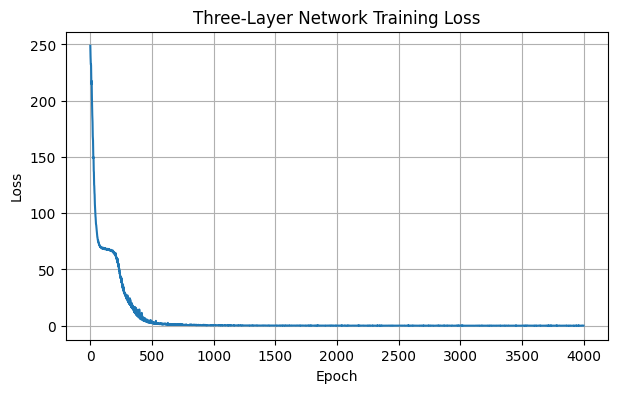

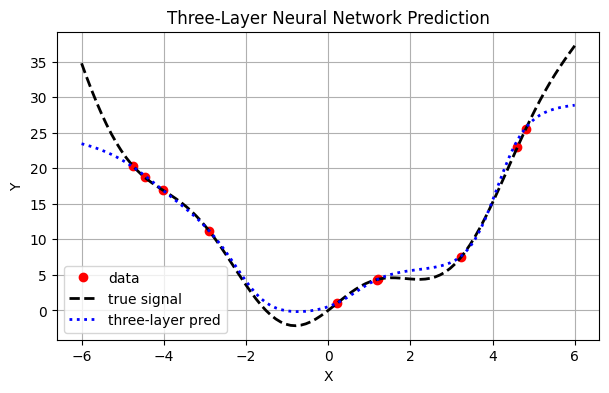

In [80]:
plt.figure(figsize=(7, 4))
plt.plot(three_history['loss'], linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Three-Layer Network Training Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(X.flatten(), Y.flatten(), 'ro', markerfacecolor='r', label='data')
plt.plot(X_test.flatten(), Y_test.flatten(), '--k', linewidth=2, label='true signal')
plt.plot(X_test.flatten(), Yhat_three.flatten(), ':b', linewidth=2, label='three-layer pred')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Three-Layer Neural Network Prediction')
plt.grid(True)
plt.legend()
plt.show()


## 7. Compare the Single-Layer, Two-Layer, and Three-Layer Models

The single-layer model is linear, while the two-layer and three-layer models are nonlinear because they include hidden layers with nonlinear activation functions.


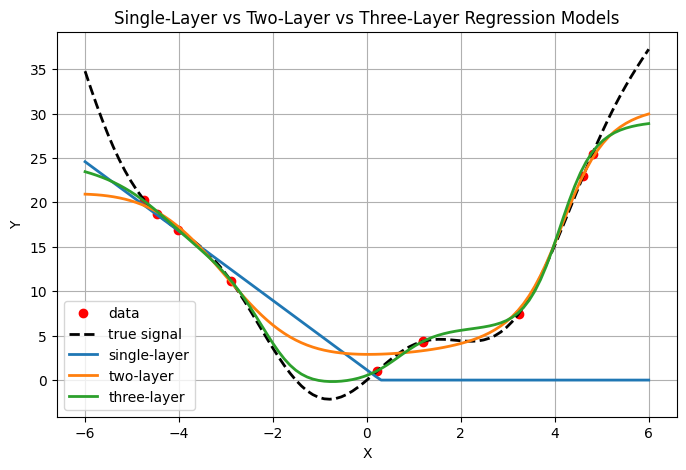

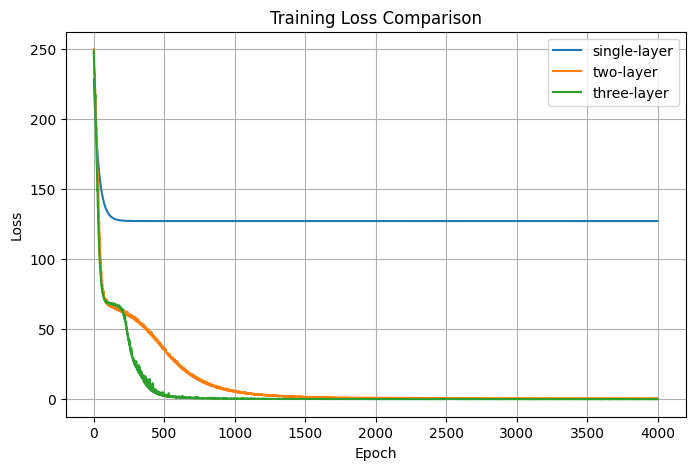

Final single-layer training loss: 127.306858
Final two-layer training loss:    0.703345
Final three-layer training loss:  0.093961


In [81]:
plt.figure(figsize=(8, 5))
plt.plot(X.flatten(), Y.flatten(), 'ro', markerfacecolor='r', label='data')
plt.plot(X_test.flatten(), Y_test.flatten(), '--k', linewidth=2, label='true signal')
plt.plot(X_test.flatten(), Yhat_single.flatten(), linewidth=2, label='single-layer')
plt.plot(X_test.flatten(), Yhat_two.flatten(), linewidth=2, label='two-layer')
plt.plot(X_test.flatten(), Yhat_three.flatten(), linewidth=2, label='three-layer')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Single-Layer vs Two-Layer vs Three-Layer Regression Models')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(single_history['loss'], linewidth=1.5, label='single-layer')
plt.plot(two_history['loss'], linewidth=1.5, label='two-layer')
plt.plot(three_history['loss'], linewidth=1.5, label='three-layer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.grid(True)
plt.legend()
plt.show()

print(f"Final single-layer training loss: {single_history['loss'][-1]:.6f}")
print(f"Final two-layer training loss:    {two_history['loss'][-1]:.6f}")
print(f"Final three-layer training loss:  {three_history['loss'][-1]:.6f}")


## 8. Summary

- The **single-layer neural network** is a direct input-output model. With a linear output activation, it is linear regression.
- The **two-layer neural network** adds one hidden layer, allowing the model to fit nonlinear relationships.
- The **three-layer neural network** adds a second hidden layer, increasing model flexibility.
- Since the dataset has only ten training points, deeper models may fit the training data better but should be interpreted carefully because they may overfit.
